In [89]:
from time import sleep

import numpy as np
import os
import matplotlib.pyplot as plt

from suspension_designer.document import Document, MotionDocument
from suspension_designer.solver import solve_at_time

doc: MotionDocument = Document.load("./user_data/my_motion.proj")
print(doc.editor_filepath)



epsilon_values = np.logspace(-6, -15, num=1000)
time_values = np.zeros_like(epsilon_values)
iter_values = np.zeros_like(epsilon_values)

for i, epsilon in enumerate(epsilon_values):
    result = solve_at_time(doc.motion_data.variables, 0.1, doc.scene_state, max_iterations=1e4, epsilon=epsilon)
    iter_values[i] = result.iterations
    time_values[i] = result.time*1e3


c:\Users\thero\Documents\projects\Coding\suspension_designer\user_data\./basic_suspension.proj


[-17.28377289 -38.18661538]


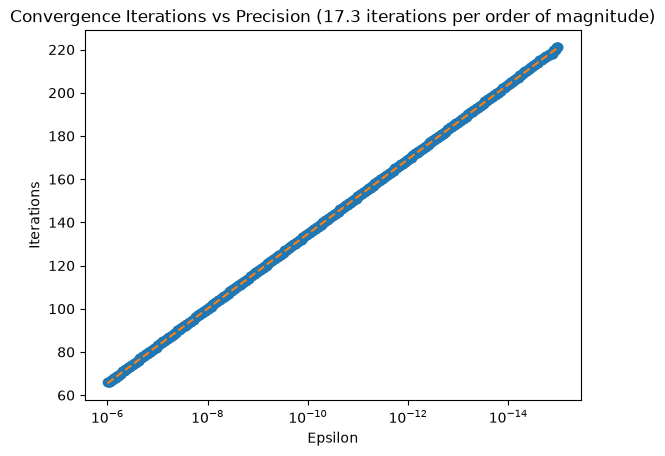

In [90]:
fig, ax = plt.subplots()
poly = np.polyfit(np.log10(epsilon_values), iter_values, 1)
print(poly)

ax.plot(epsilon_values, iter_values, 'o')
ax.plot(epsilon_values, np.polyval(poly, np.log10(epsilon_values)), '--')
ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel('Epsilon')
ax.set_ylabel('Iterations')
ax.set_title(f'Convergence Iterations vs Precision ({abs(poly[0]):.1f} iterations per order of magnitude)')
plt.show()

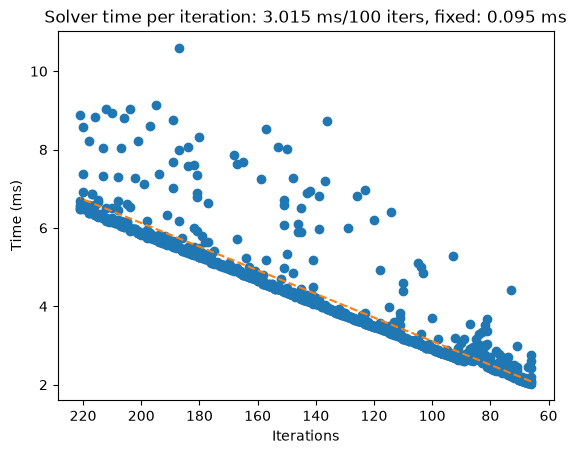

In [91]:
fig, ax = plt.subplots()

best_fit = np.polyfit(iter_values, time_values, 1)

ax.plot(iter_values, time_values, 'o')
ax.plot(iter_values, np.polyval(best_fit, iter_values), '--')
ax.invert_xaxis()
ax.set_xlabel('Iterations')
ax.set_ylabel('Time (ms)')
ax.set_title(f'Solver time per iteration: {best_fit[0]*100:.3f} ms/100 iters, fixed: {best_fit[1]:.3f} ms')
plt.show()